# Example usage of the Yen ODE solver library

In [1]:
from numba import njit
import numpy as np
import matplotlib.pyplot as plt
from yen import RK4Solver
from yen import RK45Solver
from yen import DOP853Solver

## Josephson Junction RCSJ-model

\begin{equation}
\begin{cases}
\frac{dV}{dt} = I_c + A\sin(u) - \beta V - \sin\varphi\\
\frac{d\varphi}{dt} = V \\
\frac{du}{dt} = \omega
\end{cases}
\tag{1}
\end{equation}

In [2]:
@njit
def jj_system(t, y, p):
    V, ph, u = y

    dV  = p[0] + p[1]*np.sin(u) - p[2] * V - np.sin(ph)
    dph = V
    du  = p[3]

    return np.array([dV, dph, du])

In [3]:
solver = RK4Solver(
    function = jj_system,
    y0       = np.array([0.0, 0.0, 0.0]),
    params   = np.array([0.1, 0.5, 0.2, 2.0])
)

In [4]:
T, Y = solver.solve(200.0, 5e-2)
V_vals = Y[:, 0]
phi_vals = Y[:, 1]

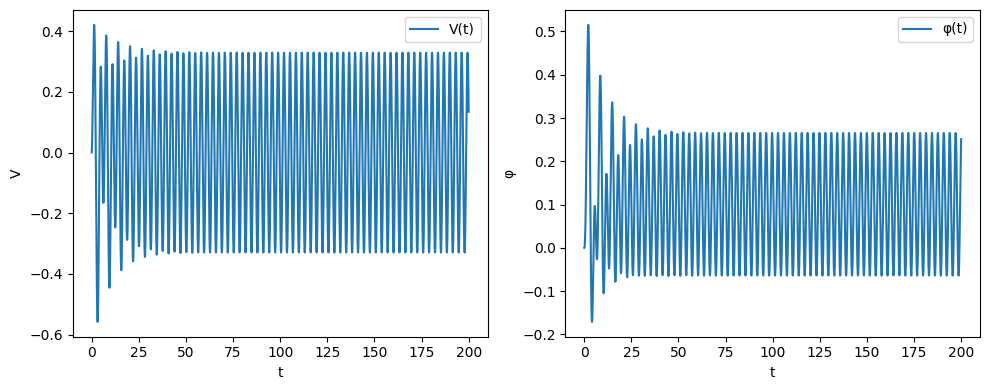

In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(T, V_vals, label='V(t)')
plt.xlabel('t')
plt.ylabel('V')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(T, phi_vals, label='φ(t)')
plt.xlabel('t')
plt.ylabel('φ')

plt.legend()
plt.tight_layout()
plt.show()

In [6]:
solver = RK45Solver(
    function = jj_system,
    y0       = np.array([0.0, 0.0, 0.0]),
    params   = np.array([0.1, 0.5, 0.2, 2.0])
)

In [7]:
T, Y = solver.solve(200.0, 5e-2)
V_vals = Y[:, 0]
phi_vals = Y[:, 1]

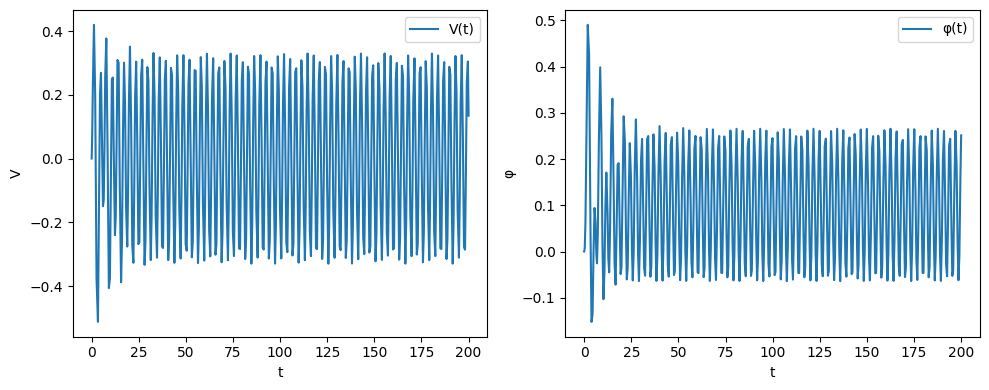

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(T, V_vals, label='V(t)')
plt.xlabel('t')
plt.ylabel('V')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(T, phi_vals, label='φ(t)')
plt.xlabel('t')
plt.ylabel('φ')

plt.legend()
plt.tight_layout()
plt.show()

In [9]:
solver = DOP853Solver(
    function = jj_system,
    y0       = np.array([0.0, 0.0, 0.0]),
    params   = np.array([0.1, 0.5, 0.2, 2.0])
)

In [10]:
T, Y = solver.solve(200.0, 5e-2)
V_vals = Y[:, 0]
phi_vals = Y[:, 1]

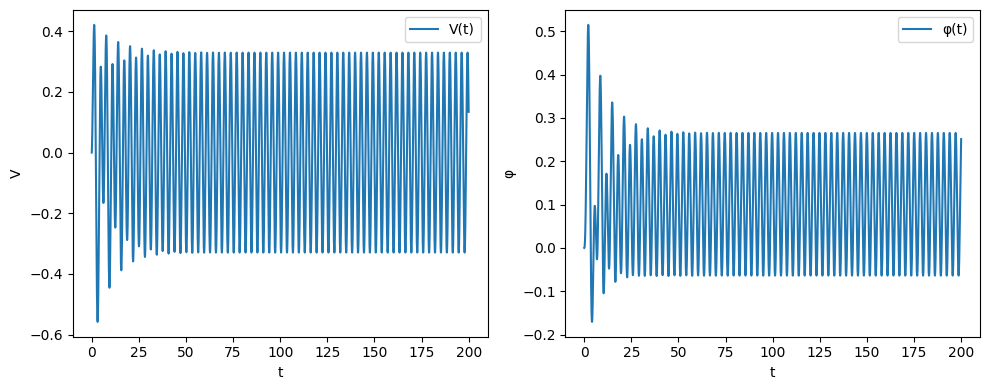

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(T, V_vals, label='V(t)')
plt.xlabel('t')
plt.ylabel('V')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(T, phi_vals, label='φ(t)')
plt.xlabel('t')
plt.ylabel('φ')

plt.legend()
plt.tight_layout()
plt.show()